# 🏏 IPL Data Analysis (2008–2026)

- Cleaned and preprocessed the IPL dataset by handling missing values.
- Performed exploratory data analysis to identify top-performing teams.
- Analyzed toss decisions and their impact on match outcomes.
- Examined venue and city-wise match distributions.
- Calculated team win percentages and scoring patterns.
- Visualized insights using Matplotlib.

## Step 1 : Load & Inspect Data

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ipl_comprehensive_dataset.csv")

In [3]:
len(df) # this the total matches

1243

In [4]:
df.shape

(1243, 31)

In [5]:
df.head(2)

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2007/08,1.0,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2007/08,2.0,2008-04-19,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."


In [6]:
df.tail(2)

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
1241,Indian Premier League,2026,NaN,2026-05-29,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,...,SJ Nogajski,AT Holdstock,UV Gandhe,T20,20,6,male,club,"TU Deshpande, YBK Jaiswal, V Suryavanshi, Dhru...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,..."
1242,Indian Premier League,2026,NaN,2026-05-31,Ahmedabad,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,...,Nitin Menon,J Madanagopal,VK Sharma,T20,20,6,male,club,"M Prasidh Krishna, B Sai Sudharsan, Shubman Gi...","JA Duffy, VR Iyer, V Kohli, D Padikkal, RM Pat..."


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_name       1243 non-null   object 
 1   season           1243 non-null   object 
 2   match_number     1169 non-null   float64
 3   date             1243 non-null   object 
 4   city             1243 non-null   object 
 5   venue            1243 non-null   object 
 6   team1            1243 non-null   object 
 7   team2            1243 non-null   object 
 8   toss_winner      1243 non-null   object 
 9   toss_decision    1243 non-null   object 
 10  team1_runs       1243 non-null   int64  
 11  team1_wickets    1243 non-null   int64  
 12  team2_runs       1243 non-null   int64  
 13  team2_wickets    1243 non-null   int64  
 14  winner           1218 non-null   object 
 15  result_type      1243 non-null   object 
 16  win_by_runs      1243 non-null   int64  
 17  win_by_wickets

## Step 2 : Data Cleaning & Preprocessing

In [8]:
df.isnull().sum()

event_name          0
season              0
match_number       74
date                0
city                0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
team1_runs          0
team1_wickets       0
team2_runs          0
team2_wickets       0
winner             25
result_type         0
win_by_runs         0
win_by_wickets      0
player_of_match     9
match_referee       0
umpire1             0
umpire2             0
tv_umpire           0
reserve_umpire      0
match_type          0
overs_limit         0
balls_per_over      0
gender              0
team_type           0
team1_players       0
team2_players       0
dtype: int64

In [9]:
df[df["winner"].isnull()][["season","team1","team2","date"]]

,season,team1,team2,date
66,2009,Kolkata Knight Riders,Rajasthan Royals,2009-04-23
130,2009/10,Chennai Super Kings,Kings XI Punjab,2010-03-21
241,2011,Delhi Daredevils,Pune Warriors,2011-05-21
328,2013,Sunrisers Hyderabad,Royal Challengers Bangalore,2013-04-07
342,2013,Royal Challengers Bangalore,Delhi Daredevils,2013-04-16
416,2014,Kolkata Knight Riders,Rajasthan Royals,2014-04-29
475,2015,Rajasthan Royals,Kings XI Punjab,2015-04-21
485,2015,Royal Challengers Bangalore,Rajasthan Royals,2015-04-29
511,2015,Royal Challengers Bangalore,Delhi Daredevils,2015-05-17
610,2017,Gujarat Lions,Mumbai Indians,2017-04-29


In [10]:
df = df.dropna(subset=["winner"])

In [11]:
df["winner"].isnull().sum()

0

## Step 3 : Season-wise Analysis

In [12]:
df["season"].nunique()

19

In [13]:
df["season"].value_counts().sort_index()

season
2007/08    58
2009       56
2009/10    59
2011       72
2012       74
2013       74
2014       59
2015       56
2016       60
2017       58
2018       60
2019       57
2020/21    56
2021       59
2022       74
2023       73
2024       71
2025       70
2026       72
Name: count, dtype: int64

In [14]:
df[["season","team1","team2","winner"]].tail(4) # 2026 final and eluminate teams 

,season,team1,team2,winner
1239,2026,Royal Challengers Bengaluru,Gujarat Titans,Royal Challengers Bengaluru
1240,2026,Rajasthan Royals,Sunrisers Hyderabad,Rajasthan Royals
1241,2026,Rajasthan Royals,Gujarat Titans,Gujarat Titans
1242,2026,Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru


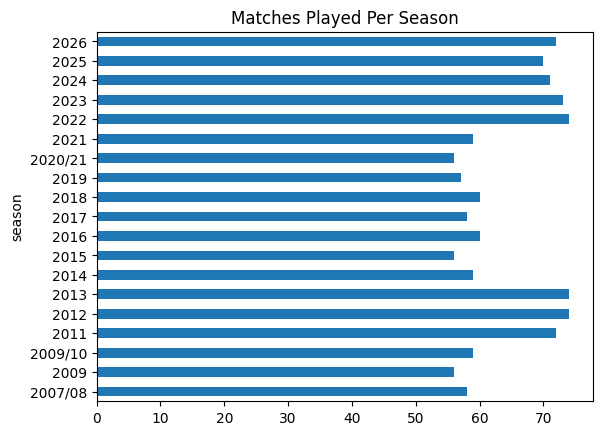

In [15]:
df["season"].value_counts().sort_index().plot(kind="barh")
plt.title("Matches Played Per Season")
plt.show()

### Analysis
The IPL has expanded significantly over the years, with the number of matches varying across seasons. This trend reflects the growth of the tournament and the introduction of new teams and formats.

## Step 4 : Top Winning Teams Analysis

This analysis focuses on identifying the most successful IPL franchises based on the total number of matches won. By examining win counts across all seasons, we can understand which teams have maintained consistent performance and dominance throughout the tournament's history.

The results reveal that a few franchises have established themselves as long-term powerhouses of the IPL. Their success can be attributed to strong team management, balanced squads, experienced leadership, and consistent performances across multiple seasons.

In [16]:
df["winner"].value_counts().head(10) # Top 10 winner team season 2008-2026

winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  47
Name: count, dtype: int64

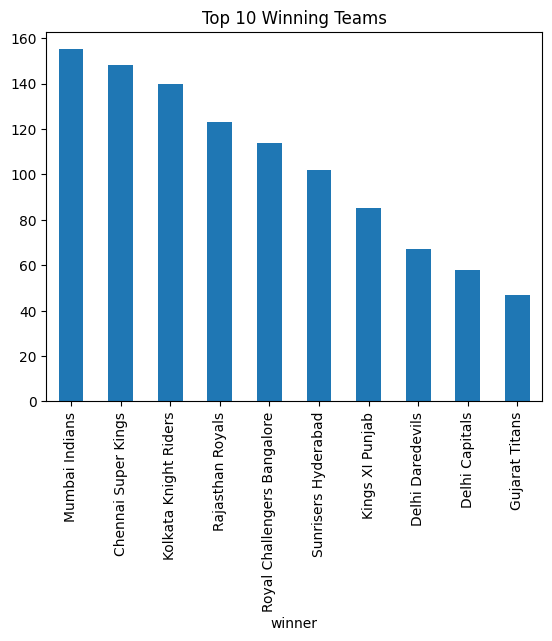

In [17]:
df["winner"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Winning Teams")
plt.show()

## 🌟 Player of the Match Analysis

The Player of the Match award is given to the most impactful performer in a match. Analyzing these awards helps identify players who consistently influenced match outcomes and delivered exceptional performances under pressure.

This analysis highlights the most dominant and match-winning players in IPL history. A high number of awards indicates not only individual brilliance but also the ability to contribute significantly to team success across multiple seasons.

In [18]:
df["player_of_match"].value_counts().head(10)

player_of_match
AB de Villiers    24
CH Gayle          22
RG Sharma         21
V Kohli           21
MS Dhoni          18
DA Warner         18
SP Narine         18
RA Jadeja         17
KL Rahul          16
SR Watson         16
Name: count, dtype: int64

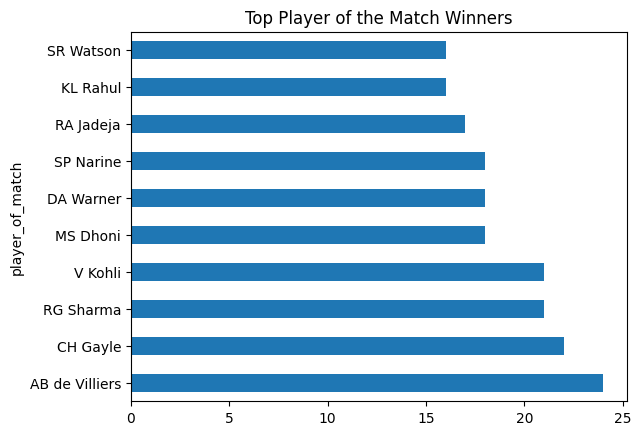

In [19]:
df["player_of_match"].value_counts().head(10).plot(kind="barh")
plt.title("Top Player of the Match Winners")
plt.show()

## 🎲 Toss Analysis

The toss is considered an important factor in T20 cricket as it can influence match strategy and decision-making. This analysis examines toss-winning trends and the decisions made by captains after winning the toss.

Understanding toss patterns helps evaluate whether teams gain a significant advantage before the match even begins.

In [20]:
df["toss_winner"].value_counts().head(10)

toss_winner
Mumbai Indians                 157
Rajasthan Royals               133
Kolkata Knight Riders          133
Chennai Super Kings            131
Royal Challengers Bangalore    110
Sunrisers Hyderabad             98
Kings XI Punjab                 83
Delhi Daredevils                79
Delhi Capitals                  66
Deccan Chargers                 43
Name: count, dtype: int64

In [21]:
df["toss_decision"].value_counts()

toss_decision
field    810
bat      408
Name: count, dtype: int64

In [22]:
(df["toss_winner"] == df["winner"]).sum()

628

In [23]:
((df["toss_winner"] == df["winner"]).sum() / len(df)) * 100

51.55993431855501

## 🌍 City-wise Match Distribution Analysis

IPL matches have been hosted across multiple cities in India and abroad. This analysis identifies the locations that have hosted the highest number of matches.

Understanding city-wise distribution provides insights into major cricketing hubs and the geographical reach of the tournament.

In [24]:
df["city"].value_counts().head(10)

city
Mumbai        186
Kolkata       105
Delhi         101
Chennai        96
Hyderabad      88
Jaipur         68
Bangalore      62
Chandigarh     61
Ahmedabad      52
Pune           51
Name: count, dtype: int64

<Axes: ylabel='city'>

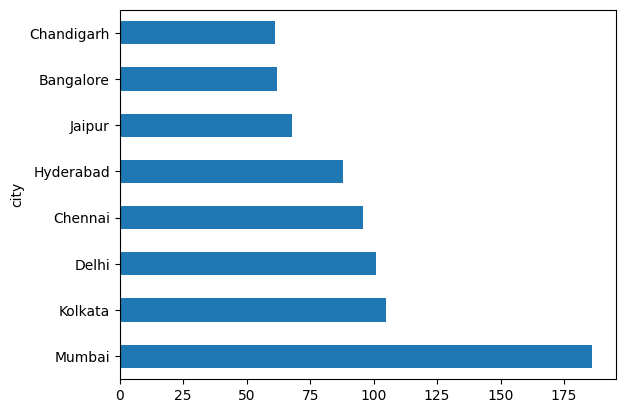

In [25]:
df["city"].value_counts().head(8).plot(kind="barh")

## 🏟️ Venue Analysis

Venues play a crucial role in shaping match outcomes, as pitch conditions and ground dimensions vary across stadiums. This analysis identifies the venues that have hosted the highest number of IPL matches.

By studying venue distribution, we can understand which stadiums have been the most active and important locations throughout IPL history.

In [26]:
df["venue"].value_counts().head(10)

venue
Eden Gardens                                 77
Wankhede Stadium                             72
M Chinnaswamy Stadium                        62
Feroz Shah Kotla                             59
Wankhede Stadium, Mumbai                     59
Rajiv Gandhi International Stadium, Uppal    48
Sawai Mansingh Stadium                       47
MA Chidambaram Stadium, Chepauk              47
Dubai International Cricket Stadium          43
Narendra Modi Stadium, Ahmedabad             41
Name: count, dtype: int64

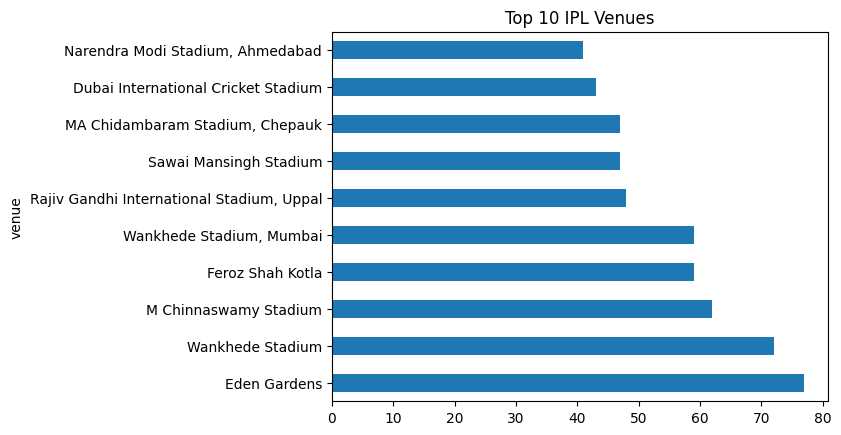

In [27]:
df["venue"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 IPL Venues")
plt.show()

## 📈 Scoring Analysis

Scoring patterns are one of the most important aspects of T20 cricket. This analysis explores the highest scores and average team scores recorded in IPL matches.

Understanding scoring trends helps evaluate batting performance and the evolution of aggressive gameplay in the tournament.

In [28]:
print(df["team1_runs"].max())
print(df["team2_runs"].max())

287
265


In [29]:
df[df["team1_runs"] == df["team1_runs"].max()][
    ["season","team1","team2","team1_runs","winner"]
]

,season,team1,team2,team1_runs,winner
1053,2024,Sunrisers Hyderabad,Royal Challengers Bengaluru,287,Sunrisers Hyderabad


In [30]:
df[df["team2_runs"] == df["team2_runs"].max()][
    ["season","team1","team2","team2_runs","winner"]
]

,season,team1,team2,team2_runs,winner
1203,2026,Delhi Capitals,Punjab Kings,265,Punjab Kings


In [31]:
df["team1_runs"].mean()

166.22413793103448

In [32]:
df["team2_runs"].mean()

158.11247947454845

In [33]:
matches_won = df["winner"].value_counts()
matches_won.head(5) # top 5 win teams 2008 - 2026

winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Name: count, dtype: int64

<Axes: ylabel='winner'>

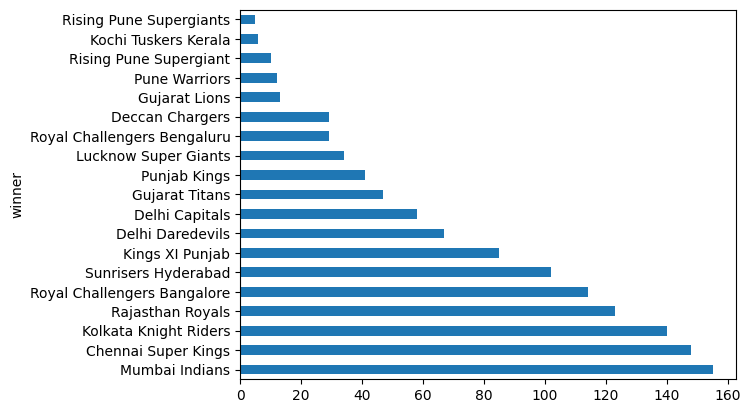

In [34]:
matches_won = df["winner"].value_counts().plot(kind="barh")
matches_won

## 📊 Team Win Percentage Analysis

While total wins indicate success, win percentage provides a better measure of team efficiency. It shows how effectively a team converts its matches into victories over time.

This analysis helps identify the most consistent and successful teams in IPL history by comparing matches won against matches played.

In [35]:
teams = pd.concat([df["team1"], df["team2"]])
matches_played = teams.value_counts()

In [36]:
matches_won = df["winner"].value_counts()

In [37]:
win_percentage = (matches_won / matches_played) * 100
win_percentage.sort_values(ascending=False)

Royal Challengers Bengaluru    63.043478
Rising Pune Supergiant         62.500000
Gujarat Titans                 61.038961
Chennai Super Kings            56.060606
Mumbai Indians                 54.006969
Kolkata Knight Riders          51.660517
Delhi Capitals                 50.877193
Rajasthan Royals               50.204082
Sunrisers Hyderabad            49.514563
Royal Challengers Bangalore    48.717949
Lucknow Super Giants           48.571429
Punjab Kings                   48.235294
Kings XI Punjab                45.698925
Gujarat Lions                  44.827586
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               42.405063
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.666667
Name: count, dtype: float64

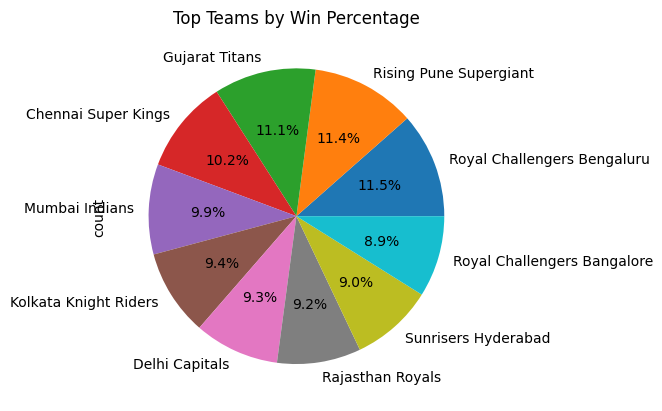

In [38]:
win_percentage.sort_values(ascending=False).head(10).plot(kind="pie",autopct="%1.1f%%")
plt.title("Top Teams by Win Percentage")
plt.show()